"""
adl_theory.py

Teaching toolkit for exploring the dynamics of
Autoregressive Distributed Lag (ADL) models.

Author: Miguel A. Arranz
License: MIT

Version: 0.1.0
"""

# ADL Theory

## Dynamic Econometric Models (Time Series Analysis)

**Author:** Miguel A. Arranz  
**Version:** 0.1.0  
**Date:** 21 July 2026

---

This notebook accompanies the module `adl_theory.py`.

Its purpose is to illustrate the theoretical properties of
Autoregressive Distributed Lag (ADL) models, including

- Stability analysis
- Dynamic effects
- Cumulative dynamic effects
- Long-run effects
- Mean and median lags
- Interactive visualizations

In [1]:
#import importlib
#import adl_theory as adl

#importlib.reload(adl)

In [2]:
%load_ext autoreload
%autoreload 2

import adl_theory as adl

## Example 1

Consider the ADL(1,2) model

$$
y_t
=
0.8y_{t-1}
+
0.5x_t
+
0.3x_{t-1}
+
u_t.
$$

In [3]:
# import adl_theory as adl

In [4]:
phi = [0.8]
beta = [0.5, 0.3]

stability = adl.adl_stability(phi)



In [5]:
# help(adl.adl_stability)

In [6]:
print(stability)

{'phi': array([0.8]), 'order': 1, 'roots': array([1.25]), 'inverse_roots': array([0.8]), 'stable': np.True_, 'max_inverse_root': np.float64(0.8)}


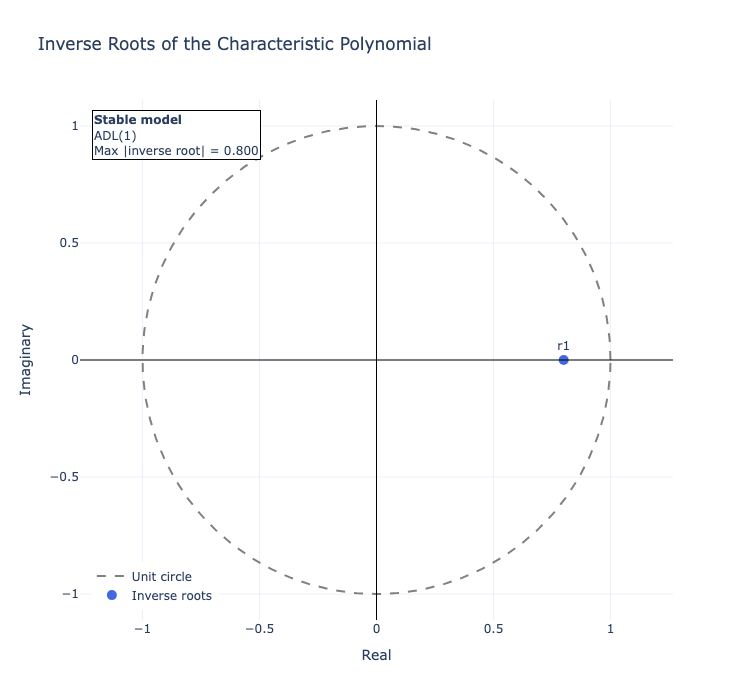

In [7]:
fig = adl.plot_inverse_roots(stability)
fig.show()

## Dynamic effects

The dynamic multipliers describe the response of \(y_t\) over time to a
permanent one-unit increase in $x_t$.

For an ADL$(p,q)$ model,

$$
\Phi(L)y_t = B(L)x_t + \varepsilon_t,
$$

the dynamic effects satisfy

$$
\psi_0 = \beta_0,
$$

and, for \(h \geq 1\),

$$
\psi_h
=
\beta_h
+
\sum_{i=1}^{\min(p,h)}
\phi_i \psi_{h-i},
$$

where \(\beta_h=0\) when \(h>q\).

In [8]:
results = adl.adl_dynamic_effects(phi, beta)


In [9]:
results["table"].head()

,Lag,Dynamic Effect,Cumulative Effect,% Total Effect,% Cumulative Effect
0,0,0.5000,0.5000,12.50,12.50
1,1,0.7000,1.2000,17.50,30.00
2,2,0.5600,1.7600,14.00,44.00
3,3,0.4480,2.2080,11.20,55.20
4,4,0.3584,2.5664,8.96,64.16


In [10]:
results["summary"]

{'stable': np.True_,
 'horizon': 21,
 'long_run_effect': np.float64(4.000000000000001),
 'mean_lag': np.float64(4.375000000000001),
 'median_lag': 3,
 'tolerance': 0.99,
 'automatic_horizon': True}

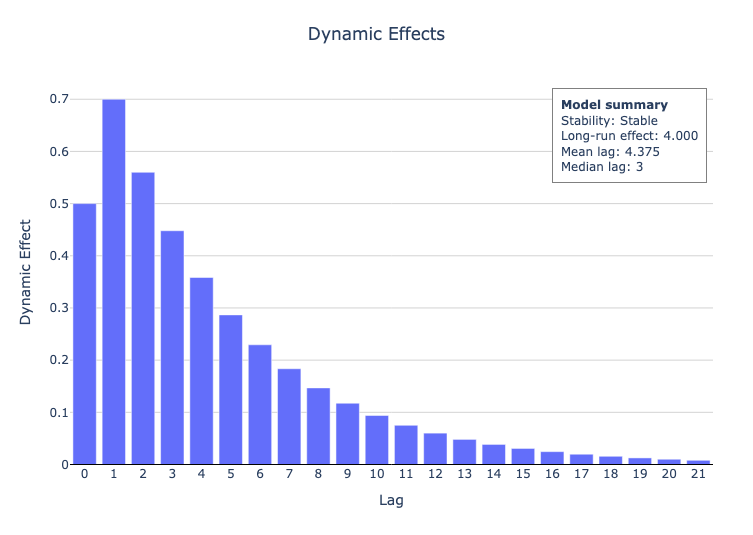

In [11]:

fig = adl.plot_dynamic_effects(results)
fig.show()

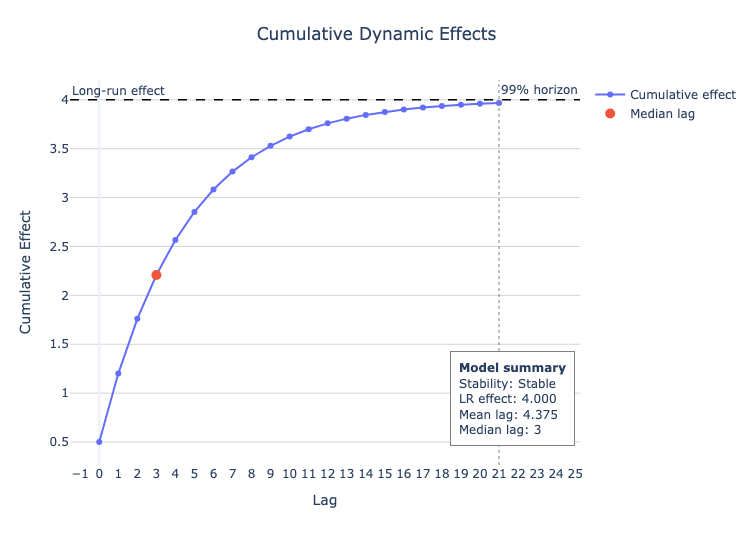

In [12]:
fig = adl.plot_cumulative_effects(results)
fig.show()

### Summary

In [13]:
adl.adl_summary(results)

Statistic,Value
Stability,Stable
Long-run effect,4.0000
Mean lag,4.3750
Median lag,3
Selected horizon,21
Horizon method,Automatic (99% threshold)


# Sanity Checks

## Case 1: $\phi=0.8$ 

In [14]:
phi = [0.8]
beta = [0.5, 0.3]

stability = adl.adl_stability(phi)

In [15]:
print(stability)

{'phi': array([0.8]), 'order': 1, 'roots': array([1.25]), 'inverse_roots': array([0.8]), 'stable': np.True_, 'max_inverse_root': np.float64(0.8)}


## Case 2: $\phi=1.25$

In [16]:
phi = [1.25]
beta = [0.5, 0.3]

stability = adl.adl_stability(phi)

In [17]:
print(stability)

{'phi': array([1.25]), 'order': 1, 'roots': array([0.8]), 'inverse_roots': array([1.25]), 'stable': np.False_, 'max_inverse_root': np.float64(1.25)}


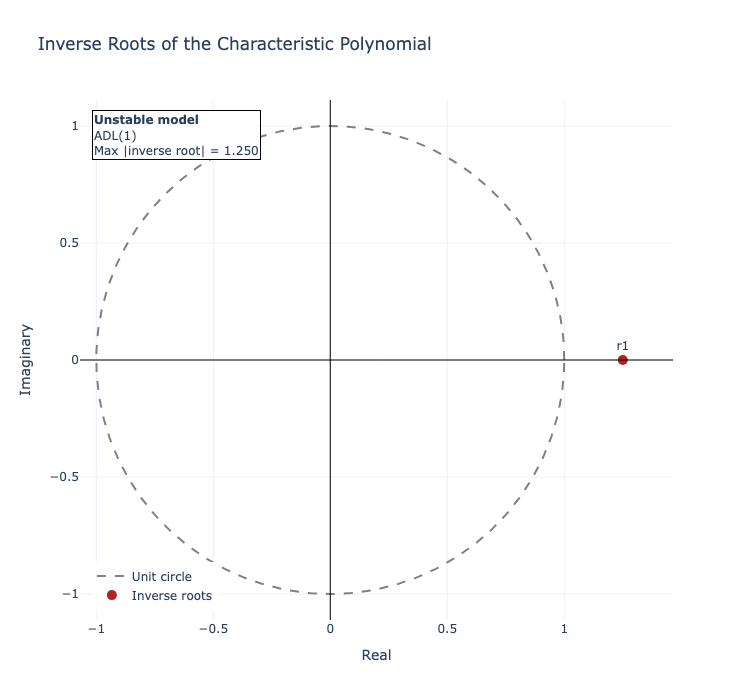

In [18]:
stability = adl.adl_stability(phi)

fig = adl.plot_inverse_roots(stability)

fig.show()